In [1]:
import pandas as pd
from sklearn import metrics
from scipy.io import loadmat
from os.path import exists
from tqdm import tqdm
from scipy.linalg import toeplitz
import time
import scipy
import os
import matplotlib.colors as mcolors 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from importlib import reload
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
#import cooler
#import cooltools
import glob
import scanpy as sc
import math

source_path = os.path.abspath("../utilities/")
sys.path.append(source_path)
import utils as ut
import matrix
import matrix_v2 

## Pore-C

In [2]:
resolution = 1000000
#chrom = "chr7"
pop_path = f"/scratch/indikar_root/indikar1/jduhamel/pore_c/population_mESC_1000000_features_en.h5ad"
sc_path = f"/scratch/indikar_root/indikar1/jduhamel/pore_c/singlecell_mESC_1000000_features_en.h5ad"
core_path = f"/scratch/indikar_root/indikar1/jduhamel/pore_c/population_mESC_100000_core.h5ad"


#file_list = sorted(glob.glob(f"{dpath}*_{resolution}_{chrom}*"))
#print(file_list)

#population_path = file_list[0]
#singlecell_path = file_list[1]
population_path = pop_path
singlecell_path = sc_path

print()

print(f"{population_path=}")
print(f"{singlecell_path=}")
print(f"{core_path=}")


population_path='/scratch/indikar_root/indikar1/jduhamel/pore_c/population_mESC_1000000_features_en.h5ad'
singlecell_path='/scratch/indikar_root/indikar1/jduhamel/pore_c/singlecell_mESC_1000000_features_en.h5ad'
core_path='/scratch/indikar_root/indikar1/jduhamel/pore_c/population_mESC_100000_core.h5ad'


In [3]:
# population
start_time = time.time()  # Record the start time
adata_main = sc.read_h5ad(population_path)
bdata_main = sc.read_h5ad(singlecell_path)
cdata_main = sc.read_h5ad(core_path)
end_time = time.time()  # Record the end time
print(f"Time taken to read the file: {end_time - start_time:.2f} seconds")
sc.logging.print_memory_usage()

adata_main.obsm

Time taken to read the file: 493.41 seconds
Memory usage: current 30.18 GB, difference +30.18 GB


/nfs/turbo/umms-indikar/Joseph/conda_envs/pore_c/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AxisArrays with keys: A, A_kr, A_oe

In [4]:
adata = adata_main.copy()
bdata = bdata_main.copy()
cdata = cdata_main.copy()

print("done!")

done!


In [5]:
adata.obs.head()

,bin_index,bin_start,bin_end,bin,chrom,chrom_bin,degree,genes,n_genes,ATACSeq_1,...,RNA_3,RNA_4,RNA_5,RNA_6,PolII,degree_outlier,global_hge_logexp_unweighted,scalar_curvature,normalized_scalar_curvature,abs_normalized_edge_curvature
bin_name,,,,,,,,,,,,,,,,,,,,,
chr9:121,0,121000000,122000000,1394,9,121,3532,Gm47092;Higd1a;Gm47108;Gask1a;Lyzl4os;Gm47112;...,41,0.826484,...,0.162437,0.225783,0.573875,0.122417,1.016765,False,0.000428,-9300499.0,-3045.350033,3045.350033
chr19:26,1,26000000,27000000,2436,19,26,3346,Gm50378;Smarca2;Gm50376;Gm48775;Gm815;1700048O...,11,0.497386,...,0.132291,0.094680,0.141617,0.084908,0.417178,False,0.000421,-8314541.0,-2880.991337,2880.991337
chr4:127,2,127000000,128000000,665,4,127,3768,Gjb3;Gm22221;Gm12943;Zmym6;Tmem35b;Gjb5;Gm1294...,16,0.754788,...,0.293742,0.247401,0.906364,0.256514,0.750054,False,0.000433,-10683981.0,-3262.284275,3262.284275
chr10:57,4,57000000,58000000,1455,10,57,3285,Serinc1;Smpdl3a;Rpl48-ps1;Gm19256;Gm48055;Fabp...,14,0.472903,...,0.233549,0.215554,0.490113,0.182086,0.176728,False,0.000425,-7936616.0,-2815.401206,2815.401206
chr12:8,5,8000000,9000000,1659,12,8,3557,Gm56512;Ldah;5033421B08Rik;Rhob;Gm33037;Laptm4...,25,0.690311,...,0.283553,0.190379,0.617768,0.222526,0.741199,False,0.000426,-9343189.0,-3056.326137,3056.326137


In [6]:
def find_outliers_iqr(df_column):
  """
  Identifies outliers in a pandas DataFrame column using the IQR method.

  Args:
    df_column: A pandas Series representing the column to analyze.

  Returns:
    A boolean mask with True for outliers and False otherwise.
  """
  Q1 = df_column.quantile(0.25)
  Q3 = df_column.quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  return (df_column < lower_bound) | (df_column > upper_bound)

#adata.obs['degree_outlier'] = find_outliers_iqr(adata.obs['chrom_degree'])
adata.obs[['chrom_bin', 'degree', 'degree_outlier']].sort_values(by='degree', ascending=False).head()

,chrom_bin,degree,degree_outlier
bin_name,,,
chr8:46,46,4392,False
chr8:117,117,4390,False
chr7:7,7,4389,False
chr8:118,118,4388,False
chr8:18,18,4384,False


A.shape=(2335, 2335) B.shape=(2579, 2579)


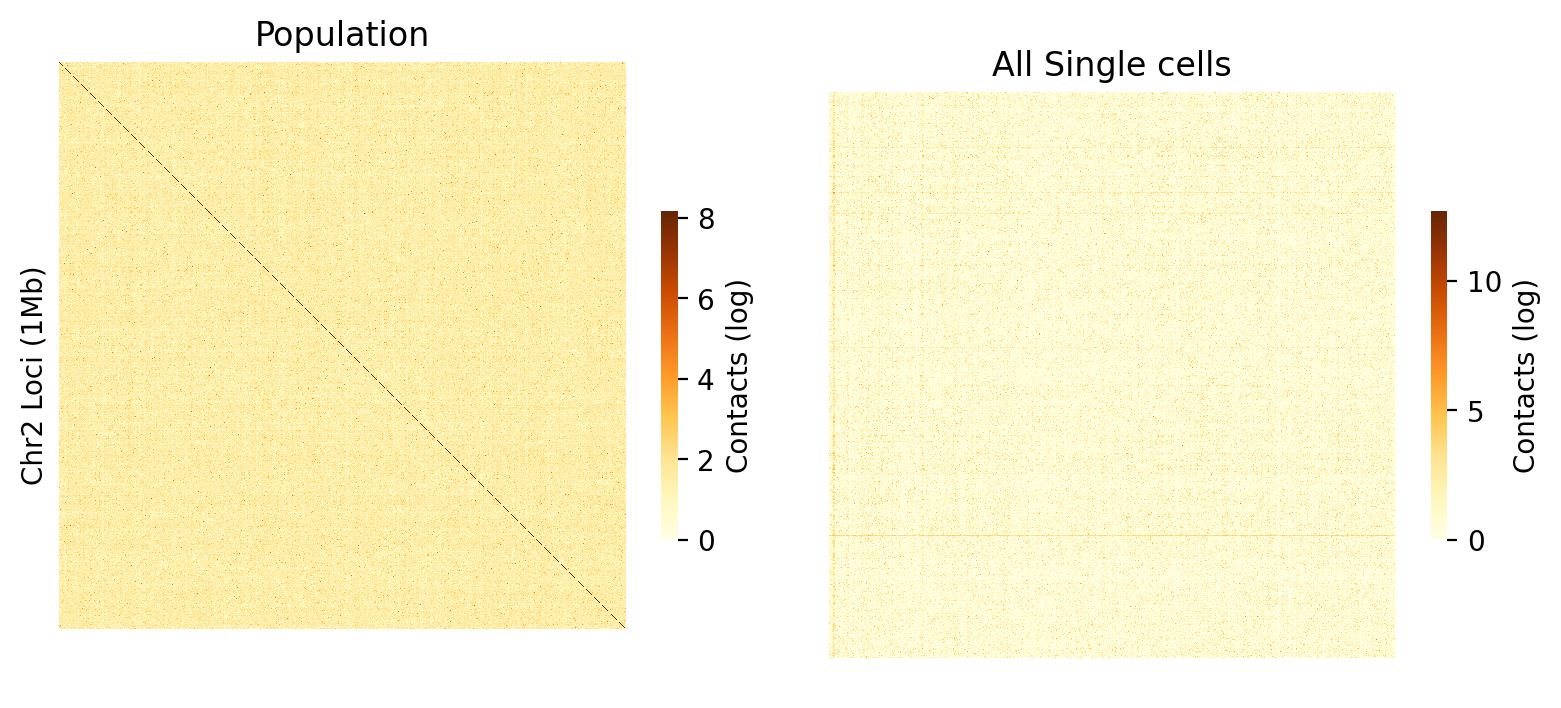

In [7]:
from scipy.sparse import issparse

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 8, 5
cmap = 'YlOrBr'
layer = 'A'
log = True

A = adata.obsm[layer]
B = bdata.obsm[layer]

# obsm now holds sparse matrices (keep_sparse=True); seaborn needs dense 2-D.
# These are small node x node matrices (~2.5k x 2.5k), so densifying is cheap.
A = A.toarray() if issparse(A) else np.asarray(A)
B = B.toarray() if issparse(B) else np.asarray(B)

cbar_label = f"Contacts"
if log:
    A = np.log1p(A)
    B = np.log1p(B)
    cbar_label = f"Contacts (log)"

print(f"{A.shape=} {B.shape=}")

fig, axs = plt.subplots(1, 2, sharey=True)
axs = axs.ravel()

sns.heatmap(
    A,
    square=True,
    cmap=cmap,
    cbar_kws={'shrink' : 0.35, 'label' : cbar_label},
    ax=axs[0],
)
axs[0].set_yticks([])
axs[0].set_xticks([])
axs[0].set_title(f"Population")
axs[0].set_xlabel("")
axs[0].set_ylabel(f"Chr2 Loci (1Mb)")

sns.heatmap(
    B,
    square=True,
    cmap=cmap,
    cbar_kws={'shrink' : 0.35, 'label' : cbar_label},
    ax=axs[1],
)
axs[1].set_yticks([])
axs[1].set_xticks([])
axs[1].set_title(f"All Single cells")
axs[1].set_xlabel("")
axs[1].set_ylabel(f"")

plt.tight_layout()

In [8]:
incidence_matrices = {}
cell_ids = bdata.var['basename'].unique()

# Only take the first 20 cells
cell_ids_subset = cell_ids[:20]
num_cells = len(cell_ids_subset)
total_time = 0.0

for i, cell_id in enumerate(cell_ids_subset):
    start_time = time.time()

    # extract the single-cell
    sc_data = bdata[:, bdata.var['basename'] == cell_id].copy()
    H_o = sc_data.to_df()
    H_o = H_o.T.drop_duplicates().T  # Transpose, drop duplicates, transpose back
    H_o.columns = [f"{cell_id}_{x}" for x in H_o.columns]

    incidence_matrices[cell_id] = H_o

    # Timing info
    elapsed_time = time.time() - start_time
    total_time += elapsed_time

    print(f"Processed {i+1}/{num_cells} cells. "
          f"Time for this cell: {elapsed_time:.2f} seconds, "
          f"Cumulative time: {total_time:.2f} seconds")

print("Finished processing cells.")

Processed 1/20 cells. Time for this cell: 39.57 seconds, Cumulative time: 39.57 seconds
Processed 2/20 cells. Time for this cell: 46.15 seconds, Cumulative time: 85.72 seconds
Processed 3/20 cells. Time for this cell: 24.16 seconds, Cumulative time: 109.88 seconds
Processed 4/20 cells. Time for this cell: 17.17 seconds, Cumulative time: 127.06 seconds
Processed 5/20 cells. Time for this cell: 11.04 seconds, Cumulative time: 138.10 seconds
Processed 6/20 cells. Time for this cell: 13.84 seconds, Cumulative time: 151.94 seconds
Processed 7/20 cells. Time for this cell: 27.65 seconds, Cumulative time: 179.60 seconds
Processed 8/20 cells. Time for this cell: 31.12 seconds, Cumulative time: 210.72 seconds
Processed 9/20 cells. Time for this cell: 31.32 seconds, Cumulative time: 242.03 seconds
Processed 10/20 cells. Time for this cell: 10.71 seconds, Cumulative time: 252.75 seconds
Processed 11/20 cells. Time for this cell: 9.47 seconds, Cumulative time: 262.22 seconds
Processed 12/20 cells.

In [9]:
matrix.expand_and_normalize_anndata(cdata, oe_kr=False)

Expanding input matrix...
Applying KR normalization...
Applying OE normalization...
Normalization complete.


/home/jduhamel/sc_pore_c/notebooks/utilities/matrix.py:369: RuntimeWarning: invalid value encountered in divide
  normalized_matrix = np.divide(matrix, toeplitz_matrix)


In [10]:
cdata.obsm['A']

bin_name,chr3:34,chr6:93,chr3:32,chr18:3,chr12:113,chr3:3,chr8:84,chr11:72,chr17:15,chr8:3,...,chr8:28,chr6:115,chr17:31,chr8:55,chr6:94,chr8:17,chr8:15,chr2:5,chr6:32,chr8:62
bin_name,,,,,,,,,,,,,,,,,,,,,
chr3:34,46.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
chr6:93,0.0,62.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
chr3:32,1.0,0.0,48.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
chr18:3,0.0,0.0,0.0,63.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
chr12:113,0.0,0.0,0.0,0.0,48.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr8:17,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,70.0,1.0,0.0,0.0,1.0
chr8:15,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,67.0,0.0,0.0,0.0
chr2:5,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,56.0,1.0,0.0


In [11]:
def chunk_list(lst, chunk_size):
    for i in range(0, len(lst), chunk_size):
        yield lst[i:i + chunk_size]

In [12]:
def _loci_of(H):
    """Locus (bin_name) labels for a single-cell incidence DataFrame."""
    if isinstance(H, pd.DataFrame):
        return list(H.index)
    if hasattr(H, "obs_names"):
        return list(H.obs_names)
    raise TypeError("Expected a labeled incidence DataFrame.")


def _to_labeled_dense(A, loci):
    """Densify a clique-expanded matrix into a labeled square DataFrame."""
    arr = A.toarray() if issparse(A) else np.asarray(A)
    return pd.DataFrame(arr, index=loci, columns=loci)


def _as_core_df(core):
    """Return the core as a labeled square DataFrame.

    The core (cdata.obsm['A']) is already clique-expanded and labeled,
    so this just normalizes type and sorts. Handles the case where it
    arrives sparse instead of as a DataFrame.
    """
    if isinstance(core, pd.DataFrame):
        df = core
    elif issparse(core):
        raise TypeError(
            "core is sparse with no labels — pass the labeled DataFrame "
            "version, or supply bin_name labels separately."
        )
    else:
        raise TypeError("Unsupported core type.")
    return df.sort_index(axis=0).sort_index(axis=1)


def _intersect(core_df, cell_df):
    """Restrict both matrices to shared loci, common sorted order."""
    shared = core_df.index.intersection(cell_df.index)
    if len(shared) == 0:
        return np.empty((0, 0)), np.empty((0, 0)), shared
    shared = sorted(shared)
    c = core_df.loc[shared, shared].values
    s = cell_df.loc[shared, shared].values
    return c, s, shared

def sim_recall(core_df, cell_df):
    """Option 1: fraction of the core's contacts also present in the cell."""
    c, s, shared = _intersect(core_df, cell_df)
    if len(shared) == 0:
        return 0.0
    core_mask = c != 0
    n_core = core_mask.sum()
    if n_core == 0:
        return 0.0
    return np.count_nonzero((s != 0) & core_mask) / n_core


def sim_weighted(core_df, cell_df):
    """Option 2: weighted overlap of contact magnitudes (cosine similarity)."""
    c, s, shared = _intersect(core_df, cell_df)
    if len(shared) == 0:
        return 0.0
    cv, sv = c.ravel(), s.ravel()
    denom = np.linalg.norm(cv) * np.linalg.norm(sv)
    if denom == 0:
        return 0.0
    return float(np.dot(cv, sv) / denom)


def sim_jaccard(core_df, cell_df):
    """Option 3: Jaccard index of contacts — shared / union."""
    c, s, shared = _intersect(core_df, cell_df)
    if len(shared) == 0:
        return 0.0
    core_mask = c != 0
    cell_mask = s != 0
    union = np.count_nonzero(core_mask | cell_mask)
    if union == 0:
        return 0.0
    return np.count_nonzero(core_mask & cell_mask) / union


_SIMILARITY = {
    "recall": sim_recall,
    "weighted": sim_weighted,
    "jaccard": sim_jaccard,
}

def _two_color_overlay(core_vals, cell_vals):
    """RGB image: core in magenta, cell in green, overlap toward white."""
    def norm(a):
        a = np.log1p(a.astype(float))
        m = a.max()
        return a / m if m > 0 else a

    c = norm(core_vals)
    s = norm(cell_vals)
    rgb = np.zeros((*c.shape, 3))
    rgb[..., 0] = c          # red
    rgb[..., 1] = s          # green
    rgb[..., 2] = c          # blue -> red+blue = magenta for the core
    return rgb


def plot_clique_grid_vs_core(
    incidence_matrices: dict,
    cdata,
    n_top: int = 10,
    similarity: str = "recall",
    n_cols: int = 5,
    dpi: int = 200,
    figsize: tuple = (20, 20),
    save_path: str | None = None,
):
    """Rank single cells by similarity to the core, plot the top N as
    two-color overlays (core = magenta, cell = green) on shared loci."""
    if similarity not in _SIMILARITY:
        raise ValueError(f"similarity must be one of {list(_SIMILARITY)}")
    score_fn = _SIMILARITY[similarity]

    # core is already clique-expanded + labeled
    core_df = _as_core_df(cdata.obsm["A"])

    # expand + score every single cell
    scores = {}
    cell_maps = {}
    for cell_id, H in incidence_matrices.items():
        loci = _loci_of(H)
        A = matrix.clique_expand_incidence(H, zero_diag=False)
        cell_df = _to_labeled_dense(A, loci).sort_index(axis=0).sort_index(axis=1)
        cell_maps[cell_id] = cell_df
        scores[cell_id] = score_fn(core_df, cell_df)

    top = sorted(scores, key=scores.get, reverse=True)[:n_top]
    print(f"Top {len(top)} cells by '{similarity}' similarity:")
    for cid in top:
        print(f"  cell {cid}: {scores[cid]:.3f}")

    n_cells = len(top)
    n_cols = min(n_cols, n_cells)
    n_rows = math.ceil(n_cells / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, dpi=dpi)
    axes = np.array(axes).flatten()

    for ax, cell_id in zip(axes, top):
        c, s, shared = _intersect(core_df, cell_maps[cell_id])
        if len(shared) == 0:
            ax.text(0.5, 0.5, "no shared loci", ha="center", va="center")
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(f"cell {cell_id}", fontsize=8)
            continue

        ax.imshow(_two_color_overlay(c, s), interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"cell {cell_id}  ({similarity}={scores[cell_id]:.2f})\n"
                     f"{len(shared)} shared loci", fontsize=8)
        ax.set_xlabel("")
        ax.set_ylabel("")

    for ax in axes[n_cells:]:
        ax.set_visible(False)

    handles = [
        plt.Line2D([0], [0], marker="s", color="none",
                   markerfacecolor="magenta", markersize=10, label="core only"),
        plt.Line2D([0], [0], marker="s", color="none",
                   markerfacecolor="lime", markersize=10, label="cell only"),
        plt.Line2D([0], [0], marker="s", color="none",
                   markerfacecolor="white", markeredgecolor="gray",
                   markersize=10, label="both"),
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=9)

    fig.suptitle(f"Top single cells vs. genomic core — {similarity} similarity",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()

Top 10 cells by 'recall' similarity:
  cell o3b50: 0.201
  cell o4b67: 0.076
  cell o3b43: 0.070
  cell o3b55: 0.060
  cell o3b30: 0.051
  cell o3b96: 0.042
  cell o3b03: 0.042
  cell o3b67: 0.034
  cell o1b71: 0.032
  cell o1b46: 0.031


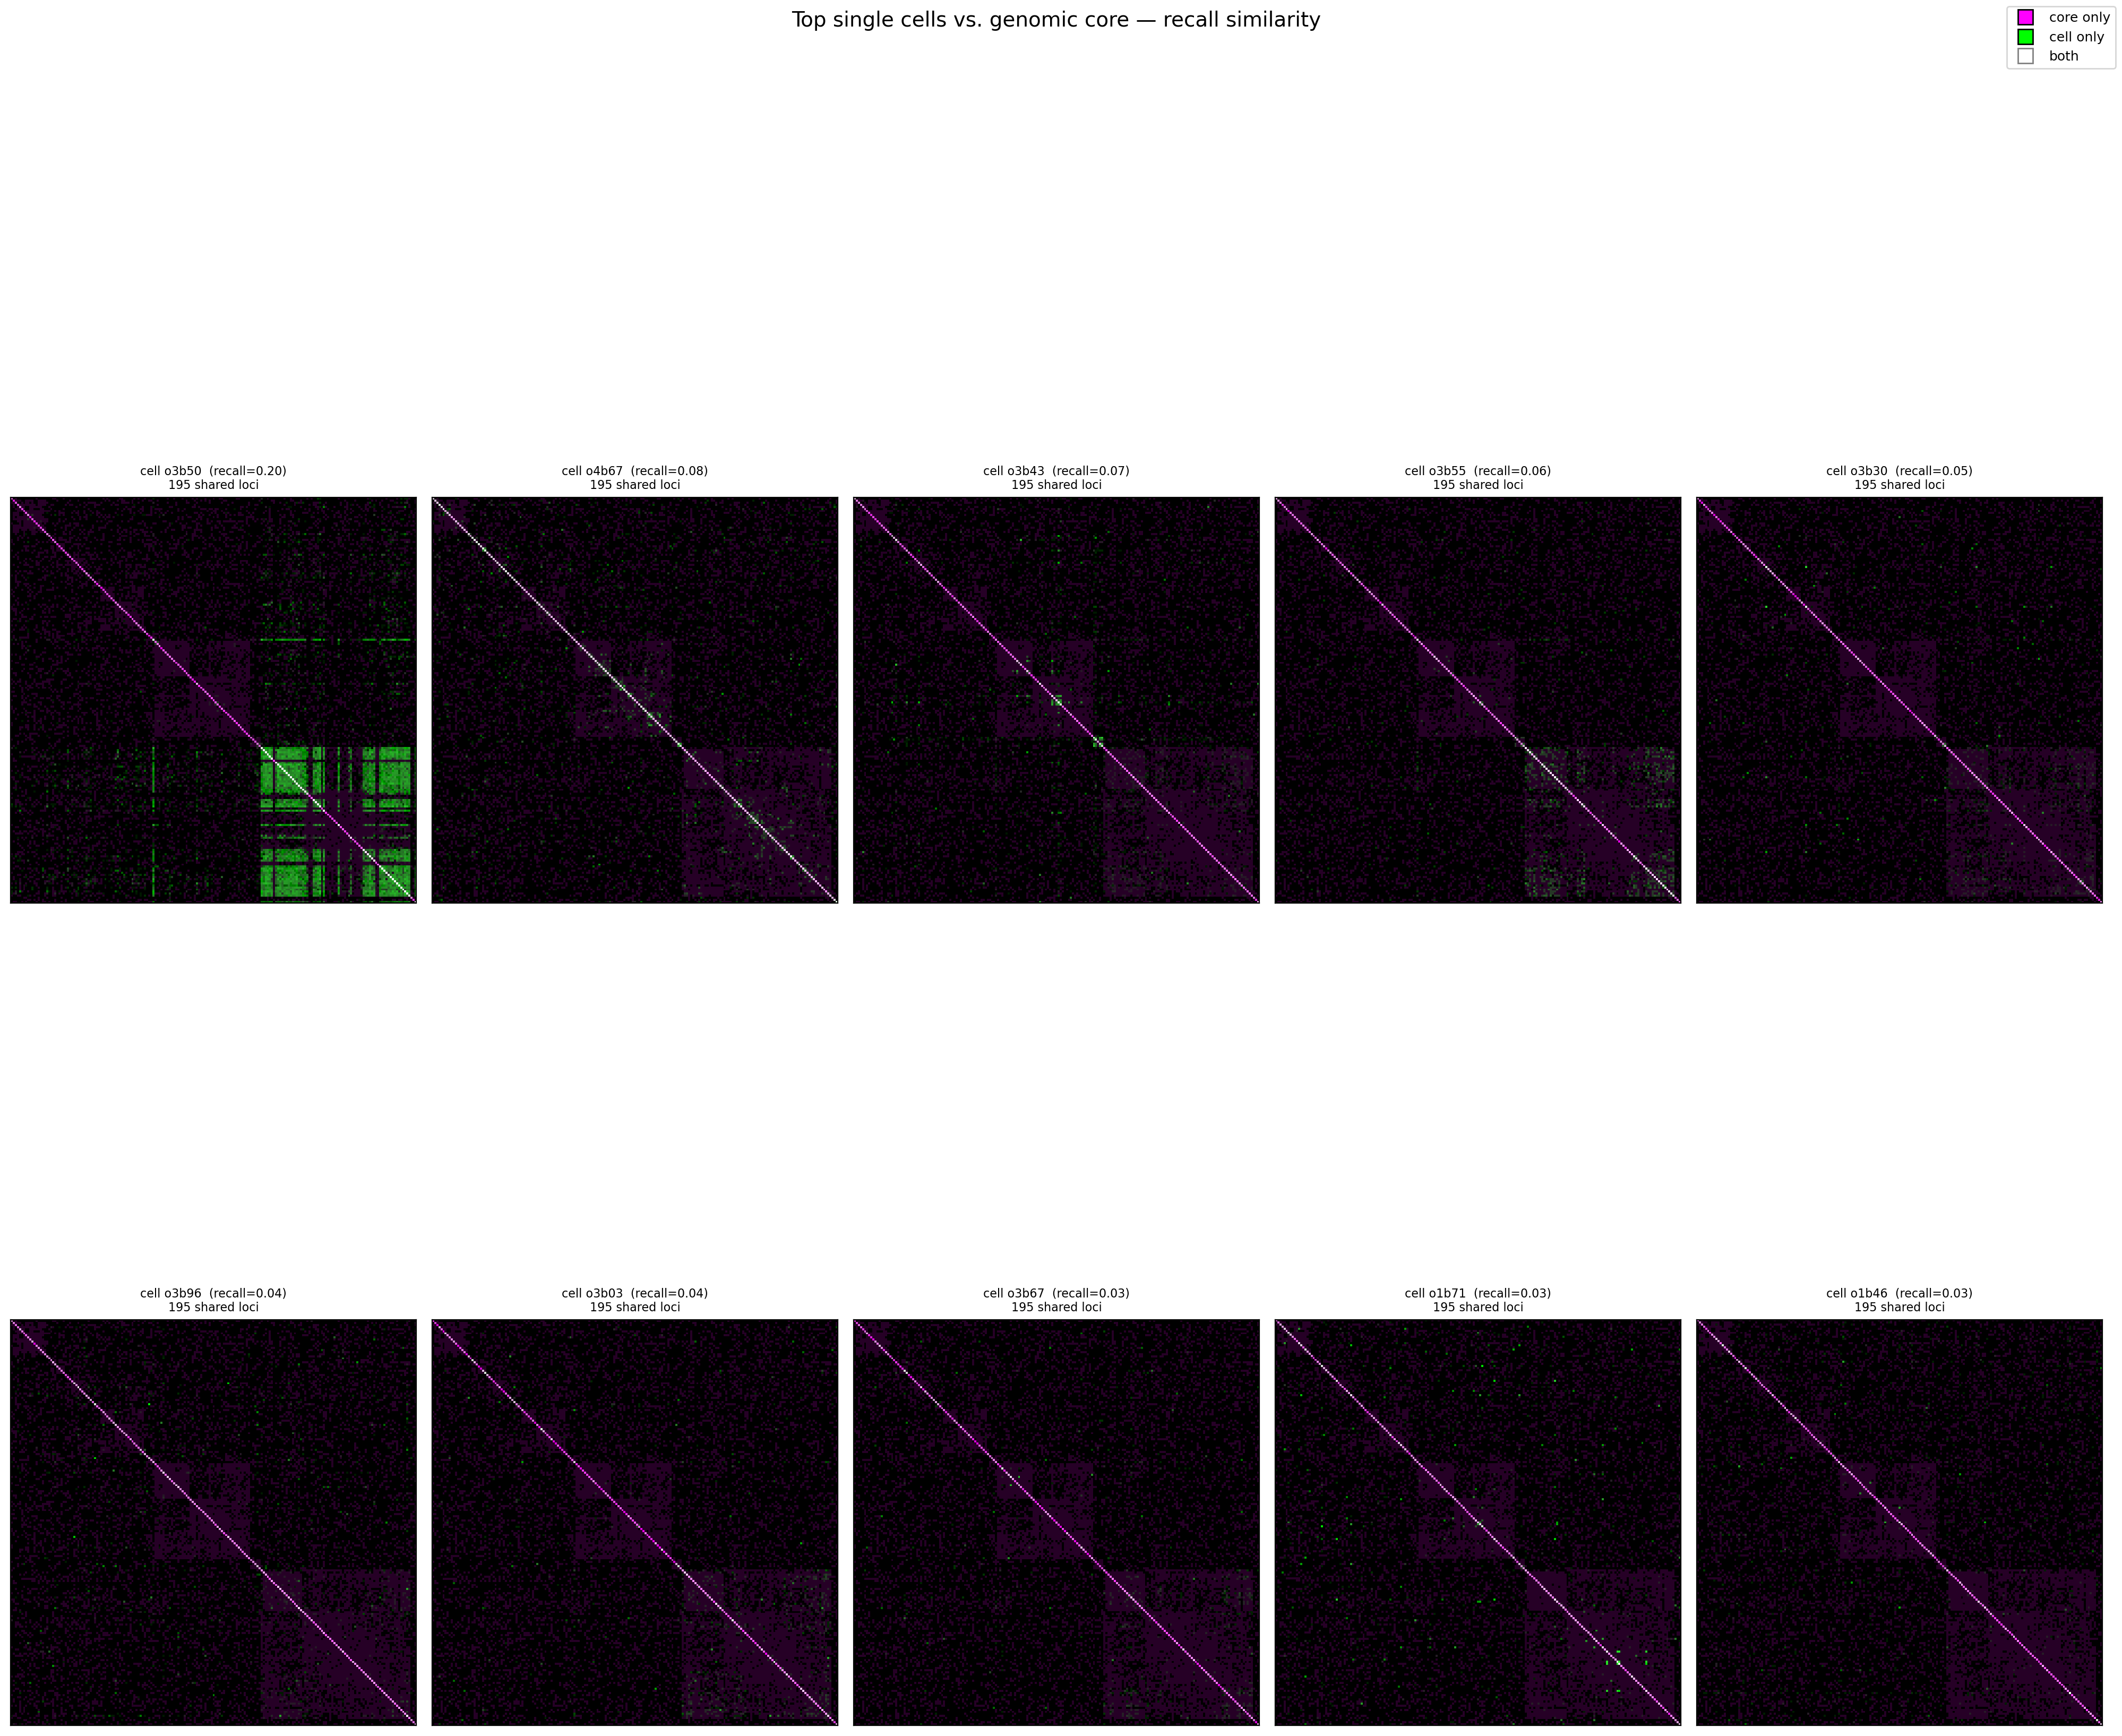

In [13]:
all_cell_ids = list(incidence_matrices.keys())

for i, batch in enumerate(chunk_list(all_cell_ids, 20)):
    plot_clique_grid_vs_core(
        incidence_matrices,
        cdata,
        n_top=10,
        similarity = "recall",
        n_cols= 5,
        dpi= 200,
        figsize=(20, 20),
        save_path=f"plots_new/grid_{i:03d}.png"
    )

## Hypergraph of Core